In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import marimo as mo


df = pd.read_csv("Train_Data.csv")

# 0. Helper functions


In [23]:
TARGET_NAME = 'Dropped_Course'


def plot_feature_dist(df: pd.DataFrame, colname: str) -> None:
    if colname not in df.columns:
        print(f"Error: Column '{colname}' not found in the DataFrame.")
        return

    s = df[colname]
    if pd.api.types.is_numeric_dtype(s):
        fig, axes = plt.subplots(1, 2, figsize=(8, 5))
        sns.boxenplot(data=df, y=colname, x=TARGET_NAME, ax=axes[0])
        axes[0].set_title(f'{colname} vs {TARGET_NAME}')
        sns.histplot(
            data=df,
            x=colname,
            hue=TARGET_NAME,
            kde=True,
            ax=axes[1],
            multiple="layer",
            alpha=0.5,
        )
        axes[1].set_title(f'{colname} Distribution Profile')
    else:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        top_categories = s.value_counts().head(20).index
        df_filtered = df[df[colname].isin(top_categories)]
        sns.countplot(
            data=df_filtered,
            y=colname,
            order=top_categories,
            ax=axes[0],
            palette="blues_r",
        )
        axes[0].set_title(f'Top 20 {colname} Overall Counts')
        sns.countplot(
            data=df_filtered,
            y=colname,
            hue=TARGET_NAME,
            order=top_categories,
            ax=axes[1],
        )
        axes[1].set_title(f'{colname} Split by Attrition')
    plt.suptitle(f'Exploratory Data Analysis for: {colname}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# 1. First insights


In [24]:
df.head()

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Practical_Hours,Theory_Hours,Registration_Days_Before,Origin_Country,Catering_Package,...,Enrollment_Type,Lanyard_Color,Client_Category,Submission_Source,Returning_Client,Agent_ID,Company_ID,Payment_Terms,Daily_Tuition_Cost,Dropped_Course
0,13766,2,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
1,78660,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
2,51396,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
3,34000,2,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
4,69025,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Orange,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0


In [25]:
df['Dropped_Course'].value_counts(normalize=True)

Dropped_Course
0    0.585608
1    0.414392
Name: proportion, dtype: float64

we see a Huge percent of drops, over $40\%$ !


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63464 entries, 0 to 63463
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Client_ID                    63464 non-null  int64  
 1   Professionals_Count          63464 non-null  int64  
 2   Students_Count               63460 non-null  float64
 3   Observers_Count              63464 non-null  int64  
 4   Course_Start_Date            63464 non-null  object 
 5   Practical_Hours              63464 non-null  int64  
 6   Theory_Hours                 63464 non-null  int64  
 7   Registration_Days_Before     60798 non-null  float64
 8   Origin_Country               62907 non-null  object 
 9   Catering_Package             63057 non-null  object 
 10  Welcome_Gift_Type            63464 non-null  object 
 11  Requested_Lab_Config         61728 non-null  object 
 12  Assigned_Lab_Config          63464 non-null  object 
 13  Prev_Course_Drop

In [27]:
df.describe()

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Practical_Hours,Theory_Hours,Registration_Days_Before,Prev_Course_Dropouts,Prev_Course_Attended,Pre_Course_Supports_Tickets,Physical_Course_Kits,Waiting_List_Days,Registration_Changes,Returning_Client,Agent_ID,Company_ID,Daily_Tuition_Cost,Dropped_Course
count,63464.000000,63464.000000,63460.000000,63464.000000,63464.000000,63464.000000,60798.000000,63464.000000,63464.000000,63464.000000,62424.000000,63464.000000,63464.000000,63464.000000,52291.000000,3120.000000,63385.000000,63464.000000
mean,39761.752616,1.835214,8.751718,0.005326,6.609054,2.164392,102.894470,0.095991,0.122967,0.513330,0.026224,3.983676,0.180039,0.027133,197.834752,5119.021474,98.847963,0.414392
std,22878.980699,0.508607,294.238584,0.089662,215.502929,1.469854,109.178824,0.448526,1.535201,0.763563,0.160202,23.195495,0.592577,0.162474,47.393068,70.106299,41.855391,0.492621
min,1.000000,0.000000,0.000000,0.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,5002.000000,0.000000,0.000000
25%,19959.750000,2.000000,0.000000,0.000000,0.000000,1.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5035.000000,75.000000,0.000000
50%,39819.500000,2.000000,0.000000,0.000000,1.000000,2.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5146.000000,94.500000,0.000000
75%,59570.250000,2.000000,0.000000,0.000000,1.000000,3.000000,150.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,218.000000,5181.000000,117.000000,1.000000
max,79330.000000,4.000000,9999.000000,10.000000,10000.000000,41.000000,629.000000,21.000000,61.000000,5.000000,3.000000,391.000000,21.000000,1.000000,322.000000,5206.000000,5400.000000,1.000000


# 2. Missing values


In [28]:
def get_null_summary(df: pd.DataFrame) -> pd.DataFrame:
    frame = pd.DataFrame({
        "null_count": df.isnull().sum(),
        "null_percent": df.isnull().mean() * 100,
    }).sort_values("null_count", ascending=False)
    return frame[frame["null_count"] > 0]


null_summary = get_null_summary(df)
null_summary

,null_count,null_percent
Company_ID,60344,95.083827
Agent_ID,11173,17.605257
Registration_Days_Before,2666,4.200807
Requested_Lab_Config,1736,2.735409
Physical_Course_Kits,1040,1.638724
Enrollment_Type,719,1.132926
Submission_Source,605,0.953296
Payment_Terms,587,0.924934
Origin_Country,557,0.877663
Catering_Package,407,0.641308


## 2.1 Conclusions so far

- `Company_ID` is $95\%$ null, should probably drop it, or turn into a dummy variable (`ordered_through_company`)

- `Agent_ID` Has a lot of nulls, but this feature might still hold usefull data due to different agents could use different "Selling" which if done too aggresivly could result in high cancelation rate per specific agent. needs to test this theory.

- The next 3 features need additional exploration inorder to decide weather theyre nulls are a big problem or not, or weather they are usefull.

- for the rest, could probably just drop the samples.


## 2.2 `Company_ID`

**Lets see whatsup with `Company_ID`**

We will split the Data set into the 95% that dosnt have a companyID and the 5% that do and see weather the mean differes by a lot in regards to drop rate.


In [29]:
print(df.groupby(df['Company_ID'].isna())['Dropped_Course'].describe())
print(
    "unique company_id list is too big: ", len(df['Company_ID'].unique().tolist()) > 10
)

              count      mean       std  min  25%  50%  75%  max
Company_ID                                                      
False        3120.0  0.212179  0.408917  0.0  0.0  0.0  0.0  1.0
True        60344.0  0.424848  0.494324  0.0  0.0  0.0  1.0  1.0
unique company_id list is too big:  True


Data suggests people invited by a Company are 2 times less likely to drop then ones who are not. since 3120 is a large enough $n$ to get a resnable mean, we should probably create a new boolean feature as suggested before, and drop this one. Before that let us check whats going on inside those 3120 samples. We also see that unique company_id's list is too big to do anything usefull with, sicne to start with we only have like 3k samples only.

- [ ] TODO: test hypothesis first

**Decision**: We will drop the `Company_ID` feature and use a dummy variable instead. Later, we could decide weather that dummy itself is usefull or not.


## 2.3 `Agent_ID`

**Lets check out Agent_ID**

1. start by seeing if any specific agent has a meaningfull difference in mean of drops
2. see if the 20% who didnt use any agent has differenc ein drop means


In [30]:
unique_agents = len(df['Agent_ID'].unique().tolist())
print("number of agents + 1 = ", unique_agents)

number of agents + 1 =  204


yiches, we have a lot of agents ... Lets keep only the ones who has a lot of samples


In [31]:
agent_counts = df['Agent_ID'].value_counts().sort_values(ascending=False)
K = 100
large_agents = agent_counts[agent_counts >= K]
large_agents

Agent_ID
184.0    22109
218.0     6551
104.0     2577
264.0     2380
219.0     1983
224.0     1312
205.0     1074
320.0     1071
158.0      892
138.0      761
139.0      744
129.0      601
220.0      513
258.0      493
222.0      358
169.0      352
118.0      336
300.0      335
306.0      310
189.0      310
144.0      277
262.0      254
133.0      246
167.0      246
277.0      240
313.0      231
318.0      225
314.0      222
321.0      220
261.0      216
178.0      200
147.0      187
317.0      183
121.0      182
217.0      168
223.0      148
190.0      134
252.0      131
111.0      129
260.0      118
250.0      114
114.0      107
199.0      106
302.0      102
Name: count, dtype: int64

cool we have a lot of agents to work with.


In [32]:
DROP_MEAN = float(df['Dropped_Course'].mean())
DROP_MEAN

0.4143924114458591

In [33]:
df_large_agents = df[df['Agent_ID'].isin(large_agents.index)]
agent_summary = df_large_agents.groupby('Agent_ID')['Dropped_Course'].agg([
    "count",
    "mean",
])
# agent_summary['drop_percent'] = (agent_summary['mean'] * 100)
agent_summary['se'] = np.sqrt(DROP_MEAN * (1 - DROP_MEAN) / agent_summary['count'])
agent_summary['diff_from_global'] = agent_summary['mean'] - DROP_MEAN
agent_summary["z_score"] = agent_summary["diff_from_global"] / agent_summary["se"]
agent_summary = agent_summary.sort_values("z_score", key=np.abs, ascending=False)
agent_summary_display = agent_summary.copy()

percent_cols = ["mean", "se", "diff_from_global"]

agent_summary_display[percent_cols] = (agent_summary_display[percent_cols] * 100).round(
    1
)

agent_summary_display = agent_summary_display.rename(
    columns={
        "mean": "drop_rate_%",
        "se": "se_%",
        "diff_from_global": "diff_from_global_%",
    }
)

agent_summary_display

,count,drop_rate_%,se_%,diff_from_global_%,z_score
Agent_ID,,,,,
218.0,6551,73.5,0.6,32.0,52.651970
104.0,2577,13.0,1.0,-28.4,-29.307036
224.0,1312,4.9,1.4,-36.6,-26.883018
264.0,2380,18.1,1.0,-23.3,-23.104359
129.0,601,80.0,2.0,38.6,19.206499
139.0,744,73.8,1.8,32.4,17.912905
314.0,222,100.0,3.3,58.6,17.712258
223.0,148,100.0,4.0,58.6,14.461998
313.0,231,85.3,3.2,43.8,13.526596


**Big finding -- Agents matter.**

Apperently some agents are terrible (as suspected) whilte some perform extremly well. we must use the data then. as for all the nulls, ill soon check thyre mean.


## 2.4 `Registration_Days_Before`


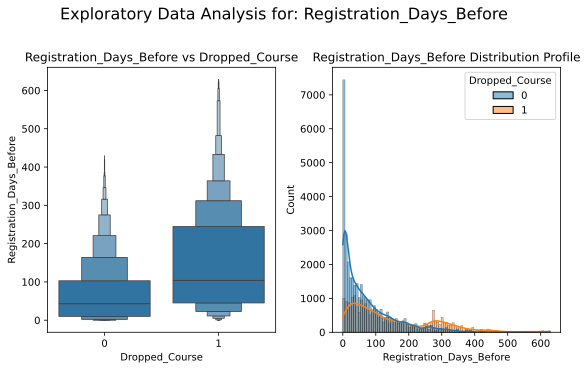

In [34]:
plot_feature_dist(df, 'Registration_Days_Before')

<Axes: title={'center': 'Distribution of Registration Days Before'}, xlabel='Dropped_Course', ylabel='Registration_Days_Before'>

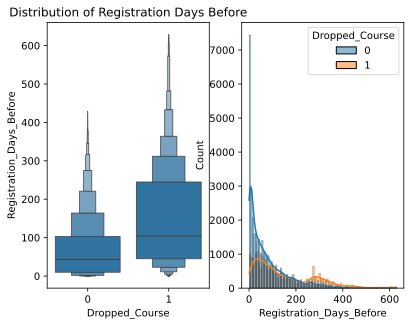

In [35]:
fig, axes = plt.subplots(1, 2)
sns.histplot(data=df, x='Registration_Days_Before', hue='Dropped_Course', kde=True)
axes[0].set_title('Distribution of Registration Days Before')
sns.boxenplot(data=df, y='Registration_Days_Before', x='Dropped_Course', ax=axes[0])

We can see that this feature is relevant. The treshhold where the mean changes is around $\approx 150$ days. Lets check to see whatsup with missing values


In [36]:
drops_150_plus = df[df['Registration_Days_Before'] >= 150]['Dropped_Course'].mean()
print('mean for eearly regs', float(drops_150_plus))
drops_days_null = df[df['Registration_Days_Before'].isna()]['Dropped_Course'].mean()
print('mean for missing vals', float(drops_days_null))
drops_up_2_150 = df[
    (df['Registration_Days_Before'] < 150) & (df['Registration_Days_Before'].notna())
]['Dropped_Course'].mean()
print('mean for rest', float(drops_up_2_150))

mean for eearly regs 0.6483718487394958
mean for missing vals 0.41522880720180044
mean for rest 0.33612781459860425


we see that missing values rows have larger drop rate then late registrations, but not as high as early registration. we should probably fill it with median, and add a dummy variable to track weather it has reg day


In [37]:
# median_days_before = df['Registration_Days_Before'].median()
# print(median_days_before)
# df['Registration_Days_Before_IsNa'] = df['Registration_Days_Before'].isna().astype(int)
# df['Registration_Days_Before'] = df['Registration_Days_Before'].fillna(
#     median_days_before
# )

# 3. Filling missing values

**So far weve:**

- droppes `Company_ID` and switched it to a dummy
- filled `Registration_Days_Before` with median

**For the rest**
since the rest dont take a large enough portion, we will use autmoated methods to fill the nulls.


## 3.2 Preprocessing Pipeline


In [38]:
def basic_preproccess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # add missing indicators for features with meaningful missingness
    for col in [
        "Agent_ID",
        "Registration_Days_Before",
        "Requested_Lab_Config",
        "Physical_Course_Kits",
    ]:
        df[f"{col}_is_missing"] = df[col].isna().astype(int)

    # Company_ID is mostly missing, so keep only whether it exists
    df["has_company_id"] = df["Company_ID"].notna().astype(int)
    df = df.drop(columns=["Company_ID"])

    # Date features // check later if its actualy needed during feature engeenering phase
    df["Course_Start_Date"] = pd.to_datetime(df["Course_Start_Date"])
    df["Course_start_month"] = df["Course_Start_Date"].dt.month
    df["Course_start_weekday"] = df["Course_Start_Date"].dt.weekday
    df = df.drop(columns=["Course_Start_Date"])

    # Normalize strings
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].str.strip().str.lower()

    # Fill missing values
    # numeric_cols = df.select_dtypes(include=["number"]).columns
    # cat_cols = df.select_dtypes(include=["object"]).columns
    # df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median()) fill seperatly
    # df[cat_cols] = df[cat_cols].fillna("unknown") fill seperatly

    return df

In [39]:
train_raw = pd.read_csv("Train_Data.csv")
test_raw = pd.read_csv("Test_Data_No_Target.csv")

train_clean = basic_preproccess(train_raw)
test_clean = basic_preproccess(test_raw)

# 4. First shot models so we have a baseline


In [40]:
import random

from sklearn.model_selection import train_test_split

X = train_clean.drop(columns=["Dropped_Course", "Client_ID"])
y = train_clean["Dropped_Course"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,  # important so we get same res every time
    stratify=y,
)

## 4.1. Raw Logistic Regression


In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import (
    SimpleImputer,
)  # fill nas using this instead of in basoc_preproccess()
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


def get_preprocess(X: pd.DataFrame):
    """
    Apply simple imputing for nulls, and standart scaler.
    """
    numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns

    numeric_transofrmer = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]
    )
    cat_transformer = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]
    )
    return ColumnTransformer([
        ('num', numeric_transofrmer, numeric_cols),
        ('cat', cat_transformer, cat_cols),
    ])


def get_lg_model(X: pd.DataFrame):
    """
    Return lg (Logistic Regression) Model.
    """
    lg_preprocess = get_preprocess(X)
    lg_model = Pipeline([
        ("preprocess", lg_preprocess),
        ("model", LogisticRegression(max_iter=1000)),
    ])
    return lg_model


lg_model = get_lg_model(X_train)
lg_model.fit(X_train, y_train)
lg_y_proba = lg_model.predict_proba(X_val)[:, 1]
RAW_LG_SCORE = roc_auc_score(y_val, lg_y_proba)

print(f"\n\nLogsitic Regression first score: {RAW_LG_SCORE}\n\n")



Logsitic Regression first score: 0.8987543602442913




**Now just test to see if the work we did in basic pre_proccess actualy gave value**


In [42]:
def test_preprocessed_data():
    """
    We wrap it in a function since we dont want all these *_raw variables in main memory
    """
    X_raw, y_raw = (
        train_raw.drop(columns=['Dropped_Course', 'Client_ID']),
        train_raw["Dropped_Course"],
    )
    X_raw_train, X_raw_val, y_raw_train, y_raw_val = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=42, stratify=y
    )
    lg_raw_model = get_lg_model(X_raw_train)
    lg_raw_model.fit(X_raw_train, y_raw_train)

    print(
        "The raw score before preprocess is: ",
        roc_auc_score(y_raw_val, lg_raw_model.predict_proba(X_raw_val)[:, 1]),
    )


test_preprocessed_data()

The raw score before preprocess is:  0.9067554948413687


### 3.1.1 CONCLUSIONS FROM LOGISTIC REGRESSION

- **Processed Data Logistic Model Score:** 0.89875

- **Unprocessed Data Logistic Model Score:** 0.90675

- The logistic regression scored very well, even without feature engineering or complex transformations. This suggests the data is highly linear.

- The unprocessed data performed slightly higher than the processed data, which could be due to the data processing.
  - This will be addressed during the feature engineering phase. KEY CHANGES MADE


## 3.2 Random Forest (Raw)


In [43]:
from sklearn.ensemble import RandomForestClassifier


def get_rf_model(X: pd.DataFrame) -> Pipeline:
    return Pipeline([
        ("preprocess", get_preprocess(X)),
        (
            'model',
            RandomForestClassifier(
                n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42
            ),
        ),
    ])


rf_model = get_rf_model(X_train)
rf_model.fit(X_train, y_train)
rf_y_proba = rf_model.predict_proba(X_val)[:, 1]

RAW_RF_SCORE = roc_auc_score(y_val, rf_y_proba)
print(f"\n\nRandom Forest Basline AOC: {RAW_RF_SCORE}")



Random Forest Basline AOC: 0.894303023358479


### 3.2.1. Conclusions from Random Forest

**Random Forest Basline AOC:** 0.89430

- It scores almost exaclty the same as the Logistic Regression model.
- Since Random Forest are less sensitive to data scale feature engeenring etc, I expect that it will be difficult to get the Forest score much higher, and therefor put most effort in opreparing for logistic regression, Which is likely to score better after data prep.
